# ĐÁP ÁN — Bài kiểm tra Lập trình phân tích dữ liệu · Buổi 1–5 (60 phút)
Notebook tham chiếu cho giảng viên. Các con số in ra ở mỗi ô là **kết quả chuẩn** để đối chiếu bài làm.

In [1]:
import re
import sqlite3
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DATA_DIR = Path('../du_lieu')

## Phần A — Python thuần: tập tin văn bản, regex, hàm (2,0 điểm)
### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex, ghi dòng lỗi ra file

In [2]:
MAU = re.compile(r'(\d{4}-\d{2}-\d{2}) \| (NV\d{3}) \| (CN\d{2}) \| ca=(SANG|CHIEU|TOI) '
                 r'\| vao=(\d{2}:\d{2}) \| ra=(\d{2}:\d{2})')

hop_le, loi = [], []
with open(DATA_DIR / 'nhat_ky_ca_lam.txt', encoding='utf-8') as f:
    for dong in f:
        dong = dong.rstrip('\n')
        if dong.strip() == '' or dong.startswith('#'):
            continue
        (hop_le if MAU.fullmatch(dong) else loi).append(dong)

with open('ca_loi.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(loi) + '\n')

print('Số dòng hợp lệ      :', len(hop_le))
print('Số dòng không hợp lệ:', len(loi))
print('Số ca theo loại     :', Counter(MAU.fullmatch(d).group(4) for d in hop_le))

Số dòng hợp lệ      : 724
Số dòng không hợp lệ: 42
Số ca theo loại     : Counter({'SANG': 242, 'CHIEU': 241, 'TOI': 241})


### A2 (1,0 đ) Hàm thống kê đi trễ & tập chi nhánh

In [3]:
GIO_BAT_DAU = {'SANG': '07:00', 'CHIEU': '12:00', 'TOI': '17:00'}


def doi_phut(hhmm):
    gio, phut = hhmm.split(':')
    return int(gio) * 60 + int(phut)


def thong_ke_di_tre(cac_dong, tre_cho_phep=5, toi_thieu=10):
    so_ca, so_tre = Counter(), Counter()
    for d in cac_dong:
        _, nv, _, ca, vao, _ = MAU.fullmatch(d).groups()
        so_ca[nv] += 1
        if doi_phut(vao) - doi_phut(GIO_BAT_DAU[ca]) > tre_cho_phep:
            so_tre[nv] += 1
    return {nv: so_tre[nv] / n for nv, n in so_ca.items() if n >= toi_thieu}


kq = thong_ke_di_tre(hop_le)
for nv in sorted(kq):
    print(f'{nv}: {kq[nv]:.3f}')
nv_max = max(kq, key=kq.get)
print(f'\nTỉ lệ đi trễ cao nhất (>= 10 ca): {nv_max} — {kq[nv_max]:.1%}')

chi_nhanh = {}
for d in hop_le:
    _, nv, cn, *_ = MAU.fullmatch(d).groups()
    chi_nhanh.setdefault(nv, set()).add(cn)
print('Làm ở đủ 4 chi nhánh:', sorted(nv for nv, s in chi_nhanh.items() if len(s) == 4))

# Kiểm tra bẫy
tat_ca = thong_ke_di_tre(hop_le, toi_thieu=0)
print('Bị loại vì < 10 ca:', {nv: f'{v:.1%}' for nv, v in tat_ca.items() if nv not in kq})
print('Nếu tính trễ khi >= 5 phút:', max(thong_ke_di_tre(hop_le, tre_cho_phep=4), key=thong_ke_di_tre(hop_le, tre_cho_phep=4).get))

NV001: 0.097
NV002: 0.081
NV003: 0.088
NV004: 0.280
NV005: 0.111
NV006: 0.087
NV007: 0.146
NV008: 0.059
NV009: 0.200
NV010: 0.036
NV011: 0.156
NV012: 0.160
NV013: 0.077
NV014: 0.031

Tỉ lệ đi trễ cao nhất (>= 10 ca): NV004 — 28.0%
Làm ở đủ 4 chi nhánh: ['NV001', 'NV002', 'NV003', 'NV015']
Bị loại vì < 10 ca: {'NV015': '75.0%'}
Nếu tính trễ khi >= 5 phút: NV004


## Phần B — NumPy & lập trình hướng đối tượng (2,0 điểm)
### B1 (0,5 đ) Ma trận doanh thu chi nhánh × ngày

In [4]:
M = np.array([[18.2, 16.5, 17.1, 19.4, 24.8, 31.2, 29.5],
              [11.4, 10.9, 12.2, 12.8, 15.1, 21.7, 20.3],
              [15.6, 14.8, 15.9, 16.4, 20.2, 26.9, 25.1],
              [ 9.8, 10.2,  9.5, 11.1, 13.6, 18.4, 17.2]])
THU = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']

tong_cn = M.sum(axis=1)
print('Tổng tuần theo chi nhánh:', tong_cn.round(1), '→ cao nhất: CN0%d' % (tong_cn.argmax() + 1))
tb_ngay = M.mean(axis=0)
print('TB theo thứ:', tb_ngay.round(2), '→ cao nhất:', THU[tb_ngay.argmax()])
ty_trong = M / M.sum(axis=1, keepdims=True)
print('Tỉ trọng T7 + CN mỗi chi nhánh:', ty_trong[:, 5:].sum(axis=1).round(3))
print('Số ô cao hơn TB của chính chi nhánh đó:', (M > M.mean(axis=1, keepdims=True)).sum())

Tổng tuần theo chi nhánh: [156.7 104.4 134.9  89.8] → cao nhất: CN01
TB theo thứ: [13.75 13.1  13.68 14.92 18.42 24.55 23.02] → cao nhất: T7
Tỉ trọng T7 + CN mỗi chi nhánh: [0.387 0.402 0.385 0.396]
Số ô cao hơn TB của chính chi nhánh đó: 12


### B2 (0,5 đ) Giải hệ phương trình tìm đơn giá nguyên liệu

In [5]:
A = np.array([[5, 10, 2],
              [3, 12, 1],
              [8, 6, 4]])
b = np.array([1470, 1069, 2052])
x = np.linalg.solve(A, b)
print('Đơn giá (nghìn đồng): cà phê/kg, sữa/lít, đường/kg =', x)
print('det(A) =', round(np.linalg.det(A), 2), '· kiểm tra A @ x == b:', np.allclose(A @ x, b))

Đơn giá (nghìn đồng): cà phê/kg, sữa/lít, đường/kg = [220.  32.  25.]
det(A) = 14.0 · kiểm tra A @ x == b: True


### B3 (1,0 đ) Lớp SanPham và SanPhamKhuyenMai

In [6]:
class SanPham:
    def __init__(self, ma, ten, gia_ban, gia_von):
        self.ma, self.ten, self.gia_von = ma, ten, gia_von
        self.gia_ban = gia_ban

    @property
    def gia_ban(self):
        return self._gia_ban

    @gia_ban.setter
    def gia_ban(self, gia):
        if gia < self.gia_von:
            raise ValueError(f'{self.ma}: giá bán {gia} thấp hơn giá vốn {self.gia_von}')
        self._gia_ban = gia

    def gia_thuc_te(self):
        return self.gia_ban

    def bien_loi_nhuan(self):
        return (self.gia_thuc_te() - self.gia_von) / self.gia_thuc_te()

    def __str__(self):
        return f'{self.ma} {self.ten}: {self.gia_thuc_te():,.0f}đ · biên LN {self.bien_loi_nhuan():.1%}'


class SanPhamKhuyenMai(SanPham):
    def __init__(self, ma, ten, gia_ban, gia_von, giam):
        super().__init__(ma, ten, gia_ban, gia_von)
        self.giam = giam

    def gia_thuc_te(self):
        return self.gia_ban * (1 - self.giam)


latte = SanPham('SP04', 'Latte', 55000, 18000)
cookie = SanPhamKhuyenMai('SP11', 'Cookie đá xay', 65000, 22000, 0.20)
print(latte)
print(cookie)
try:
    latte.gia_ban = 15000
except ValueError as e:
    print('Lỗi:', e)

SP04 Latte: 55,000đ · biên LN 67.3%
SP11 Cookie đá xay: 52,000đ · biên LN 57.7%
Lỗi: SP04: giá bán 15000 thấp hơn giá vốn 18000


## Phần C — Pandas: đọc, làm sạch, tích hợp (2,5 điểm)
### C1 (0,5 đ) Đọc dữ liệu từ CSV, Excel và SQLite

In [7]:
gd = pd.read_csv(DATA_DIR / 'giao_dich.csv')
gd['thoi_gian'] = pd.to_datetime(gd['thoi_gian'], format='%d/%m/%Y %H:%M')
kh = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='khach_hang')
hang = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='hang_thanh_vien')
with sqlite3.connect(DATA_DIR / 'san_pham.db') as con:
    sp = pd.read_sql('SELECT * FROM san_pham', con)
    cn = pd.read_sql('SELECT * FROM chi_nhanh', con)

for ten, bang in [('giao_dich', gd), ('khach_hang', kh), ('san_pham', sp), ('chi_nhanh', cn)]:
    print(f'{ten:11}: {bang.shape}')
print('\nGiá trị thiếu trong giao_dich:')
print(gd.isna().sum()[lambda s: s > 0])

giao_dich  : (2430, 9)
khach_hang : (406, 5)
san_pham   : (16, 6)
chi_nhanh  : (4, 3)

Giá trị thiếu trong giao_dich:
ma_kh       672
so_luong     62
danh_gia    509
dtype: int64


### C2 (1,0 đ) Làm sạch bảng giao dịch theo đúng 5 bước

In [8]:
n0 = len(gd)
gd = gd.drop_duplicates()                                                    # 1
n1 = len(gd)

CHUAN_KENH = {'tại quán': 'Tại quán', 'tai quan': 'Tại quán', 'mang đi': 'Mang đi',
              'mang di': 'Mang đi', 'giao hàng': 'Giao hàng', 'giao hang': 'Giao hàng'}
gd['kenh'] = gd['kenh'].str.strip().str.lower().map(CHUAN_KENH)             # 2

gd = gd[~(gd['so_luong'] > 20)]                                              # 3
n3 = len(gd)
gd['so_luong'] = gd['so_luong'].fillna(gd.groupby('kenh')['so_luong'].transform('median')).astype(int)

gd.loc[gd['thoi_gian_cho'] < 0, 'thoi_gian_cho'] = np.nan                    # 4
so_am = gd['thoi_gian_cho'].isna().sum()

q1 = gd.groupby('kenh')['thoi_gian_cho'].transform(lambda s: s.quantile(0.25))   # 5
q3 = gd.groupby('kenh')['thoi_gian_cho'].transform(lambda s: s.quantile(0.75))
tren = q3 + 1.5 * (q3 - q1)
ngoai_lai = gd['thoi_gian_cho'] > tren
print('Ngoại lai theo kênh:', gd.loc[ngoai_lai, 'kenh'].value_counts().to_dict())
q1c, q3c = gd['thoi_gian_cho'].quantile([0.25, 0.75])                        # bẫy: IQR chung cả cột
print('Nếu dùng IQR chung (ngưỡng %.1f phút):' % (q3c + 1.5 * (q3c - q1c)),
      gd.loc[gd['thoi_gian_cho'] > q3c + 1.5 * (q3c - q1c), 'kenh'].value_counts().to_dict())
gd['thoi_gian_cho'] = gd['thoi_gian_cho'].clip(upper=tren)
gd['thoi_gian_cho'] = gd['thoi_gian_cho'].fillna(gd.groupby('kenh')['thoi_gian_cho'].transform('median'))

print('Ban đầu:', n0, '· sau bước 1:', n1, f'(bỏ {n0 - n1})', '· sau bước 3:', n3, f'(bỏ {n1 - n3})')
print('Số đơn theo kênh:', gd['kenh'].value_counts().to_dict())
print('Trung vị so_luong theo kênh:', gd.groupby('kenh')['so_luong'].median().to_dict())
print('Thời gian chờ âm → NaN:', so_am)
print('Còn thiếu:', gd[['so_luong', 'thoi_gian_cho', 'kenh']].isna().sum().to_dict())

Ngoại lai theo kênh: {'Tại quán': 37, 'Mang đi': 33, 'Giao hàng': 14}
Nếu dùng IQR chung (ngưỡng 19.7 phút): {'Giao hàng': 330, 'Tại quán': 3}
Ban đầu: 2430 · sau bước 1: 2400 (bỏ 30) · sau bước 3: 2392 (bỏ 8)
Số đơn theo kênh: {'Tại quán': 1026, 'Mang đi': 877, 'Giao hàng': 489}
Trung vị so_luong theo kênh: {'Giao hàng': 2.0, 'Mang đi': 1.0, 'Tại quán': 1.0}
Thời gian chờ âm → NaN: 6
Còn thiếu: {'so_luong': 0, 'thoi_gian_cho': 0, 'kenh': 0}


### C3 (1,0 đ) Tích hợp bốn nguồn

In [9]:
sp = sp.rename(columns={'product_id': 'ma_sp'})
print('gia_ban_vat là cột dẫn xuất:', np.allclose(sp['gia_ban_vat'], sp['gia_ban'] * 1.08, atol=1))
sp = sp.drop(columns='gia_ban_vat')

print('Mã khách trùng:', kh['ma_kh'].duplicated().sum())
print('Bẫy — merge khi CHƯA khử trùng khách:', len(gd.merge(kh, on='ma_kh', how='left')), 'dòng thay vì', len(gd))
kh = kh.drop_duplicates(subset='ma_kh')
kh['gioi_tinh'] = kh['gioi_tinh'].str.strip().str.lower().map(
    {'nam': 'Nam', 'm': 'Nam', 'nữ': 'Nữ', 'nu': 'Nữ', 'f': 'Nữ'})
print('Giới tính:', kh['gioi_tinh'].value_counts().to_dict())
kh = kh.merge(hang, on='hang_thanh_vien', how='left')

khong_co_sp = ~gd['ma_sp'].isin(sp['ma_sp'])
print('Giao dịch có ma_sp ngoài danh mục:', khong_co_sp.sum())
df = (gd[~khong_co_sp]
      .merge(sp, on='ma_sp', how='left', validate='many_to_one')
      .merge(kh[['ma_kh', 'gioi_tinh', 'hang_thanh_vien', 'chiet_khau']], on='ma_kh', how='left',
             validate='many_to_one')
      .merge(cn, on='ma_cn', how='left'))
df['hang_thanh_vien'] = df['hang_thanh_vien'].fillna('Vãng lai')
df['chiet_khau'] = df['chiet_khau'].fillna(0)
df['doanh_thu'] = df['so_luong'] * df['gia_ban'] * (1 - df['chiet_khau'])
df['loi_nhuan'] = df['doanh_thu'] - df['so_luong'] * df['gia_von']

print('\nSố dòng df:', len(df), '· vãng lai:', (df['hang_thanh_vien'] == 'Vãng lai').sum())
print(f'Tổng doanh thu: {df["doanh_thu"].sum():,.0f} · lợi nhuận: {df["loi_nhuan"].sum():,.0f}')
print((df.groupby('ten_cn')['doanh_thu'].sum() / 1e6).round(1).sort_values(ascending=False))

gia_ban_vat là cột dẫn xuất: True
Mã khách trùng: 6
Bẫy — merge khi CHƯA khử trùng khách: 2418 dòng thay vì 2392
Giới tính: {'Nữ': 240, 'Nam': 160}
Giao dịch có ma_sp ngoài danh mục: 21

Số dòng df: 2371 · vãng lai: 705
Tổng doanh thu: 181,410,850 · lợi nhuận: 120,340,850
ten_cn
Nguyễn Huệ    57.4
Hoàn Kiếm     47.9
Thảo Điền     40.8
Cầu Giấy      35.3
Name: doanh_thu, dtype: float64


## Phần D — Biến đổi & thu gọn dữ liệu (1,5 điểm)
### D1 (0,75 đ) Biến đổi

In [10]:
THU_TU = {'Rất tệ': 1, 'Tệ': 2, 'Bình thường': 3, 'Tốt': 4, 'Rất tốt': 5}
df['diem_dg'] = df['danh_gia'].map(THU_TU)
mode_dg = df['diem_dg'].mode()[0]
df['diem_dg'] = df['diem_dg'].fillna(mode_dg).astype(int)
print('Mode:', mode_dg, '· phân bố:', df['diem_dg'].value_counts().sort_index().to_dict())

import scipy.stats as st
df['log_cho'] = np.log1p(df['thoi_gian_cho'])
print('Skew thoi_gian_cho:', round(st.skew(df['thoi_gian_cho']), 3), '→ sau log1p:', round(st.skew(df['log_cho']), 3))

dummy = pd.get_dummies(df['kenh'], prefix='kenh', dtype=int)
print('One-hot:', dummy.columns.tolist(), dummy.sum().to_dict())

Mode: 4.0 · phân bố: {1: 15, 2: 85, 3: 453, 4: 1299, 5: 519}
Skew thoi_gian_cho: 1.915 → sau log1p: 0.793
One-hot: ['kenh_Giao hàng', 'kenh_Mang đi', 'kenh_Tại quán'] {'kenh_Giao hàng': 486, 'kenh_Mang đi': 868, 'kenh_Tại quán': 1017}


### D2 (0,75 đ) Tổng hợp theo khách hàng & giảm chiều

In [11]:
thanh_vien = df[df['hang_thanh_vien'] != 'Vãng lai']
khach = thanh_vien.groupby('ma_kh').agg(
    so_gd=('ma_gd', 'count'),
    tong_chi=('doanh_thu', 'sum'),
    sl_tb=('so_luong', 'mean'),
    cho_tb=('thoi_gian_cho', 'mean'),
    diem_tb=('diem_dg', 'mean'),
    ti_le_giao=('kenh', lambda s: (s == 'Giao hàng').mean()),
)
khach['tong_chi'] = khach['tong_chi'] / 1e6
print('Bảng khách:', khach.shape)
khach['nhom_chi'] = pd.qcut(khach['tong_chi'], q=3, labels=['Thấp', 'Vừa', 'Cao'])
print('Nhóm chi tiêu:', khach['nhom_chi'].value_counts(sort=False).to_dict())

so = khach.drop(columns='nhom_chi')
tq = so.corr()
print(tq.round(2))
cap = [(a, b, round(tq.loc[a, b], 2)) for i, a in enumerate(tq.columns) for b in tq.columns[i + 1:] if abs(tq.loc[a, b]) > 0.7]
print('Cặp |r| > 0.7:', cap)

Z = StandardScaler().fit_transform(so)
pca = PCA(n_components=0.9).fit(Z)
print('PCA giữ >= 90%:', pca.n_components_, 'thành phần ·', PCA().fit(Z).explained_variance_ratio_.cumsum().round(3))

Bảng khách: (396, 6)
Nhóm chi tiêu: {'Thấp': 132, 'Vừa': 132, 'Cao': 132}
            so_gd  tong_chi  sl_tb  cho_tb  diem_tb  ti_le_giao
so_gd        1.00      0.90   0.26    0.05    -0.04        0.03
tong_chi     0.90      1.00   0.54    0.08    -0.04        0.06
sl_tb        0.26      0.54   1.00    0.15    -0.03        0.15
cho_tb       0.05      0.08   0.15    1.00    -0.38        0.89
diem_tb     -0.04     -0.04  -0.03   -0.38     1.00       -0.35
ti_le_giao   0.03      0.06   0.15    0.89    -0.35        1.00
Cặp |r| > 0.7: [('so_gd', 'tong_chi', np.float64(0.9)), ('cho_tb', 'ti_le_giao', np.float64(0.89))]
PCA giữ >= 90%: 4 thành phần · [0.395 0.721 0.857 0.974 0.991 1.   ]


## Phần E — Trực quan hoá (2,0 điểm)

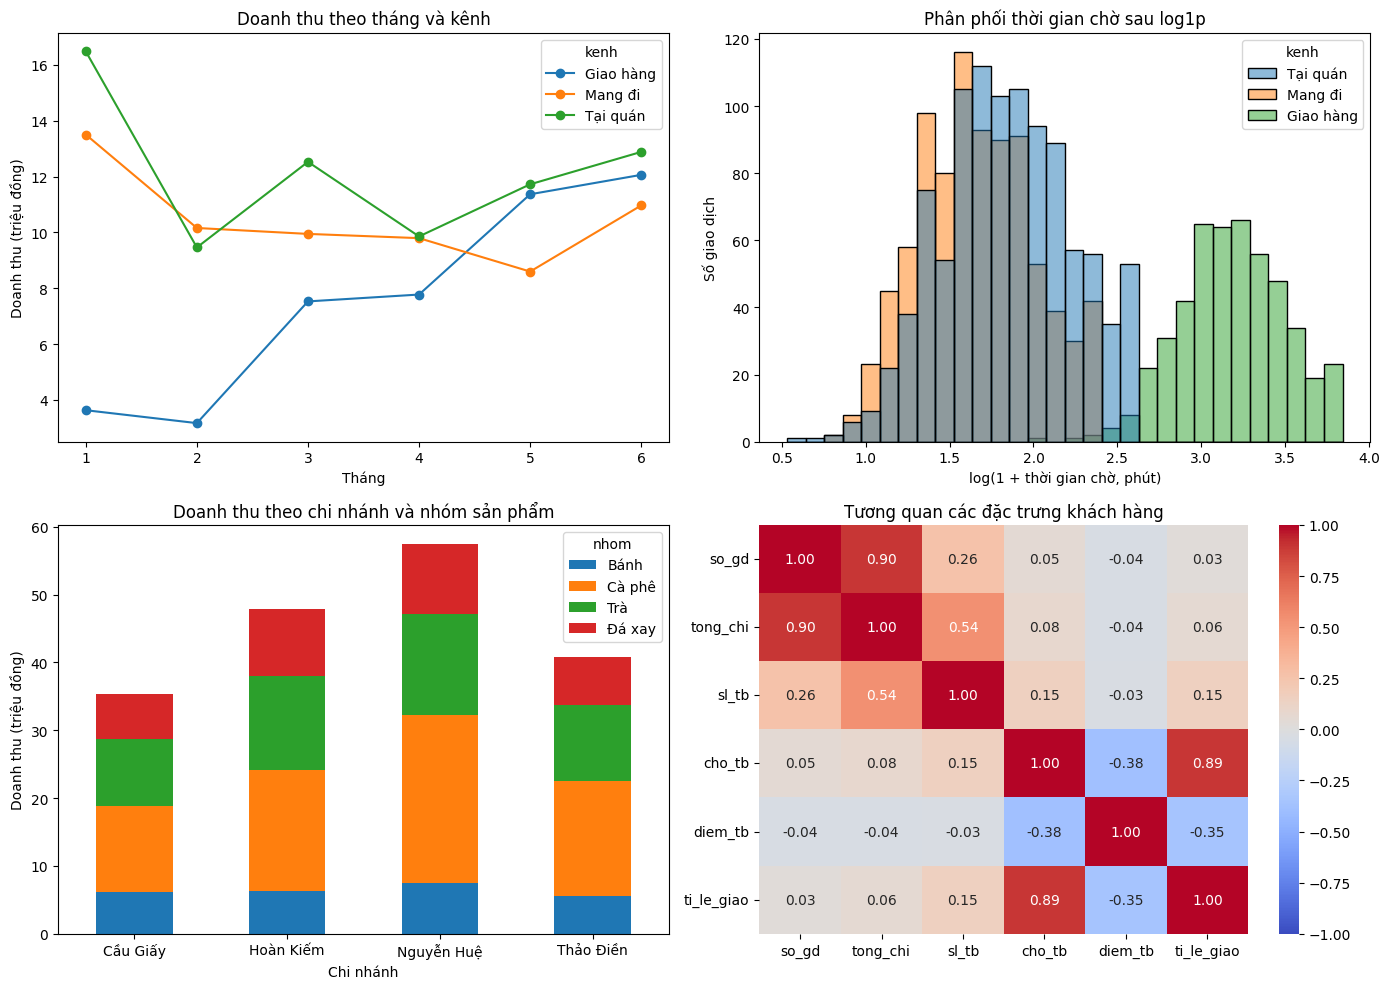

kenh       Giao hàng  Mang đi  Tại quán
thoi_gian                              
1                3.6     13.5      16.5
2                3.2     10.2       9.5
3                7.5      9.9      12.5
4                7.8      9.8       9.9
5               11.4      8.6      11.7
6               12.1     11.0      12.9
nhom        Bánh  Cà phê   Trà  Đá xay
ten_cn                                
Cầu Giấy     6.2    12.7   9.9     6.6
Hoàn Kiếm    6.3    17.9  13.9     9.9
Nguyễn Huệ   7.4    24.8  14.9    10.2
Thảo Điền    5.5    17.0  11.2     7.1


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

theo_thang = (df.groupby([df['thoi_gian'].dt.month, 'kenh'])['doanh_thu'].sum() / 1e6).unstack()
theo_thang.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set(title='Doanh thu theo tháng và kênh', xlabel='Tháng', ylabel='Doanh thu (triệu đồng)')

sns.histplot(data=df, x='log_cho', hue='kenh', bins=30, ax=axes[0, 1])
axes[0, 1].set(title='Phân phối thời gian chờ sau log1p', xlabel='log(1 + thời gian chờ, phút)', ylabel='Số giao dịch')

pv = df.pivot_table(index='ten_cn', columns='nhom', values='doanh_thu', aggfunc='sum') / 1e6
pv.plot(kind='bar', stacked=True, ax=axes[1, 0], rot=0)
axes[1, 0].set(title='Doanh thu theo chi nhánh và nhóm sản phẩm', xlabel='Chi nhánh', ylabel='Doanh thu (triệu đồng)')

sns.heatmap(tq, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Tương quan các đặc trưng khách hàng')

fig.tight_layout()
fig.savefig('bieu_do.png', dpi=150)
plt.show()
print(theo_thang.round(1))
print(pv.round(1))